Dummy image created at dummy_image.jpg
Enter the text you want to add to the image: COMPUTER VISION
Image with text saved to output_image_with_text.jpg


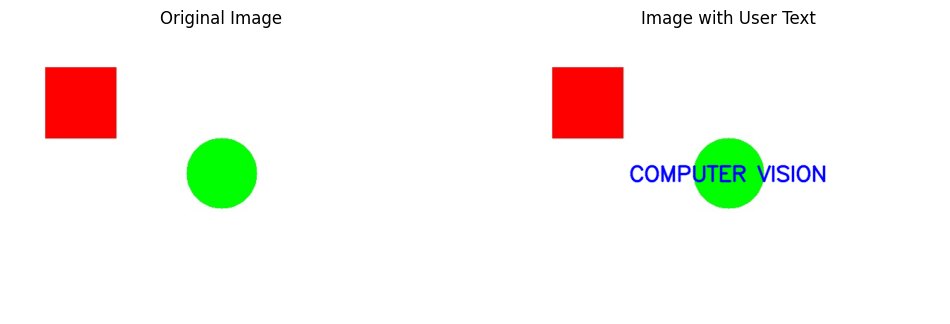

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_text_to_image(image_path, text_to_add, output_path='output_image_with_text.jpg'):
    """
    Adds user-defined text to an image using OpenCV.

    Args:
        image_path (str): The path to the input image.
        text_to_add (str): The text string to be added to the image.
        output_path (str): The path to save the output image with text.
                           Defaults to 'output_image_with_text.jpg'.

    Returns:
        numpy.ndarray: The image with the added text, or None if the image could not be loaded.
    """
    # Load the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Define text properties
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.0
    font_thickness = 2
    text_color = (255, 0, 0)  # Blue color in BGR format

    # Get text size to position it
    (text_width, text_height), baseline = cv2.getTextSize(text_to_add, font, font_scale, font_thickness)

    # Calculate image dimensions
    img_height, img_width, _ = img.shape

    # Calculate text position for centering
    # The coordinates (x, y) specify the bottom-left corner of the text string
    text_x = (img_width - text_width) // 2
    text_y = (img_height + text_height) // 2 # Adjust for baseline and vertical centering

    # Add the text to the image
    cv2.putText(img, text_to_add, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

    # Save the modified image
    cv2.imwrite(output_path, img)
    print(f"Image with text saved to {output_path}")

    return img

# --- Example Usage ---

# 1. Create a dummy image for demonstration
dummy_image_path = 'dummy_image.jpg'
width, height = 600, 400
dummy_image = np.zeros((height, width, 3), dtype=np.uint8) # Black image
dummy_image[:] = (255, 255, 255) # Make it white

# Add some initial shapes to the dummy image
cv2.circle(dummy_image, (width // 2, height // 2), 50, (0, 255, 0), -1) # Green circle
cv2.rectangle(dummy_image, (50, 50), (150, 150), (0, 0, 255), -1) # Red square

cv2.imwrite(dummy_image_path, dummy_image)
print(f"Dummy image created at {dummy_image_path}")

# 2. Define the text to add
user_text = input("Enter the text you want to add to the image: ")

# 3. Call the function to add text
image_with_text = add_text_to_image(dummy_image_path, user_text)

# 4. Display the original and modified images (using matplotlib for Colab compatibility)
if image_with_text is not None:
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(dummy_image_path), cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(image_with_text, cv2.COLOR_BGR2RGB))
    plt.title('Image with User Text')
    plt.axis('off')

    plt.show()